In [1]:
import os
import random
import numpy as np
from keras import ops
from PIL import Image
from keras.applications.resnet_v2 import preprocess_input
import matplotlib.pyplot as plt
import keras
import warnings
warnings.filterwarnings('ignore')

2025-07-25 13:52:02.522132: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-25 13:52:02.533697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753429922.546014 1019063 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753429922.549867 1019063 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753429922.560297 1019063 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

**Dataset Path**

In [2]:
LFW_DIR = "LFW/"
IMAGE_DIR = os.path.join(LFW_DIR, "lfw-deepfunneled")
PAIRS_FILE = os.path.join(LFW_DIR, "pairs.csv")

Load LFW dataset and Create pairs

In [3]:
def load_and_pair_creation_of_data(base_path, link_file, resize_shape):
    import os
    import numpy as np
    from PIL import Image

    paired_images = []
    pair_flags = []

    matches_same = []
    matches_diff = []

    with open(link_file, 'r') as reader:
        next(reader)  # ignore the first header line
        for record in reader.readlines():
            elements = record.strip().split(',')
            if len(elements) == 3 or (len(elements) == 4 and elements[3] == ''):
                person_id, img_idx1, img_idx2 = elements[0], int(elements[1]), int(elements[2])
                img_path1 = os.path.join(base_path, person_id, f"{person_id}_{img_idx1:04d}.jpg")
                img_path2 = os.path.join(base_path, person_id, f"{person_id}_{img_idx2:04d}.jpg")
                matches_same.append([img_path1, img_path2])
            elif len(elements) == 4:
                person_a, idx_a, person_b, idx_b = elements[0], int(elements[1]), elements[2], int(elements[3])
                img_path1 = os.path.join(base_path, person_a, f"{person_a}_{idx_a:04d}.jpg")
                img_path2 = os.path.join(base_path, person_b, f"{person_b}_{idx_b:04d}.jpg")
                matches_diff.append([img_path1, img_path2])

    total_pairs = matches_same + matches_diff
    flags = [0] * len(matches_same) + [1] * len(matches_diff)

    print(f"Attempting to load {len(total_pairs) * 2} image files...")
    for i in range(len(total_pairs)):
        try:
            file1, file2 = total_pairs[i]

            image1 = Image.open(file1).convert("RGB").resize(resize_shape)
            image2 = Image.open(file2).convert("RGB").resize(resize_shape)

            array1 = np.array(image1, dtype="float32")
            array2 = np.array(image2, dtype="float32")

            paired_images.append([array1, array2])
            pair_flags.append(flags[i])

        except FileNotFoundError:
            print(f"Notice: Missing image(s) in pair #{i}. Skipping.")
            continue

    print("All images loaded successfully.")
    return np.array(paired_images), np.array(pair_flags, dtype="float32")


# ------------- Execution Section -------------

data_pairs, data_labels = load_and_pair_creation_of_data(IMAGE_DIR, PAIRS_FILE, (128, 128))

# Shuffle data randomly
shuffle_order = np.random.permutation(len(data_pairs))
data_pairs = data_pairs[shuffle_order]
data_labels = data_labels[shuffle_order]

# Primary 80/20 split for training+validation and testing
main_split = int(0.8 * len(data_pairs))
data_tv, labels_tv = data_pairs[:main_split], data_labels[:main_split]
data_test, labels_test = data_pairs[main_split:], data_labels[main_split:]

# Secondary 50/50 split of training+validation into train and validation
sub_split = int(0.5 * len(data_tv))
data_train, labels_train = data_tv[:sub_split], labels_tv[:sub_split]
data_val, labels_val = data_tv[sub_split:], labels_tv[sub_split:]

print(f"\nTotal processed pairs: {len(data_pairs)}")
print("---")
print(f"Train set size:       {len(data_train)}")
print(f"Validation set size:  {len(data_val)}")
print(f"Test set size:        {len(data_test)}")
print("---")
print(f"Train pair shape:     {data_train.shape}")


Attempting to load 12000 image files...


All images loaded successfully.

Total processed pairs: 6000
---
Train set size:       2400
Validation set size:  2400
Test set size:        1200
---
Train pair shape:     (2400, 2, 128, 128, 3)


Split and preprocess the dataset

In [4]:
# Split the training pairs
x_train_1 = preprocess_input(data_train[:, 0])
x_train_2 = preprocess_input(data_train[:, 1])

# Split the test pairs
x_test_1 = preprocess_input(data_test[:, 0])
x_test_2 = preprocess_input(data_test[:, 1])

# Split the test pairs
x_val_1 = preprocess_input(data_val[:, 0])
x_val_2 = preprocess_input(data_val[:, 1])

**Define the model**

In [5]:
def euclidean_distance(vects):
    x, y = vects
    sum_square = ops.sum(ops.square(x - y), axis=1, keepdims=True)
    return ops.sqrt(ops.maximum(sum_square, keras.backend.epsilon()))

def create_embedding_network(input_shape):
    # Define the ResNet50V2 base model
    base_cnn = keras.applications.ResNet50V2(
        weights="imagenet", 
        input_shape=input_shape,
        include_top=False,
    )

    # Set layers to be trainable as requested
    trainable = False
    for layer in base_cnn.layers:
        if layer.name == "conv5_block1_out":
            trainable = True
        layer.trainable = trainable

    # Add a custom head for embedding generation
    flatten = keras.layers.Flatten()(base_cnn.output)
    x = keras.layers.Dense(512, activation="relu")(flatten)
    x = keras.layers.BatchNormalization()(x)
    output = keras.layers.Dense(256)(x) # 256-dimensional embedding

    return keras.Model(base_cnn.input, output, name="Embedding")

# Define the input shape for our LFW images
input_shape = (128,128,3)
embedding_network = create_embedding_network(input_shape)

# The Siamese network structure is IDENTICAL to the blog's
input_1 = keras.layers.Input(input_shape)
input_2 = keras.layers.Input(input_shape)

tower_1 = embedding_network(input_1)
tower_2 = embedding_network(input_2)

merge_layer = keras.layers.Lambda(euclidean_distance, output_shape=(1,))(
    [tower_1, tower_2]
)
normal_layer = keras.layers.BatchNormalization()(merge_layer)
output_layer = keras.layers.Dense(1, activation="sigmoid")(normal_layer)
siamese_model = keras.Model(inputs=[input_1, input_2], outputs=output_layer)

I0000 00:00:1753429934.687125 1019063 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5698 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


**Define Contrastive Loss Function and compile the model**

In [6]:
siamese_model.compile(
    loss="binary_crossentropy", 
    optimizer=keras.optimizers.Adam(0.0001), 
    metrics=["accuracy"]
)
siamese_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 256)       │ 40,475,904 │ input_layer_1[0]… │
│ (Functional)        │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ Embedding[0][0],  │
│                     │                   │            │ Embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1)         │          4 │ lambda[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │          2 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,475,910 (154.40 MB)

 Trainable params: 25,843,460 (98.58 MB)

 Non-trainable params: 14,632,450 (55.82 MB)

**Train the model**

In [7]:
history = siamese_model.fit(
    [x_train_1, x_train_2],
    labels_train,
    validation_data=([x_val_1, x_val_2], labels_val),
    batch_size=16,
    epochs=30,
)

Epoch 1/30


I0000 00:00:1753429942.080300 1020725 service.cc:152] XLA service 0x7da59c004c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753429942.080373 1020725 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-07-25 13:52:22.330674: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753429943.761883 1020725 cuda_dnn.cc:529] Loaded cuDNN version 90501


 10/150 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3950 - loss: 0.9002

I0000 00:00:1753429949.850081 1020725 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.4490 - loss: 0.8282 - val_accuracy: 0.5063 - val_loss: 1.3139
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7682 - loss: 0.5173 - val_accuracy: 0.5383 - val_loss: 0.7659
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9359 - loss: 0.4109 - val_accuracy: 0.5683 - val_loss: 0.7687
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9599 - loss: 0.3835 - val_accuracy: 0.5646 - val_loss: 0.7570
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9789 - loss: 0.3716 - val_accuracy: 0.5667 - val_loss: 0.7523
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9720 - loss: 0.3617 - val_accuracy: 0.5608 - val_loss: 0.7486
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9794 - loss: 0.3490 - val_accuracy: 0.5650 - val_loss: 0.7642
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9893 - loss: 0.3365 - val_accuracy: 0.56

**Visualize the Accuracy and Loss**

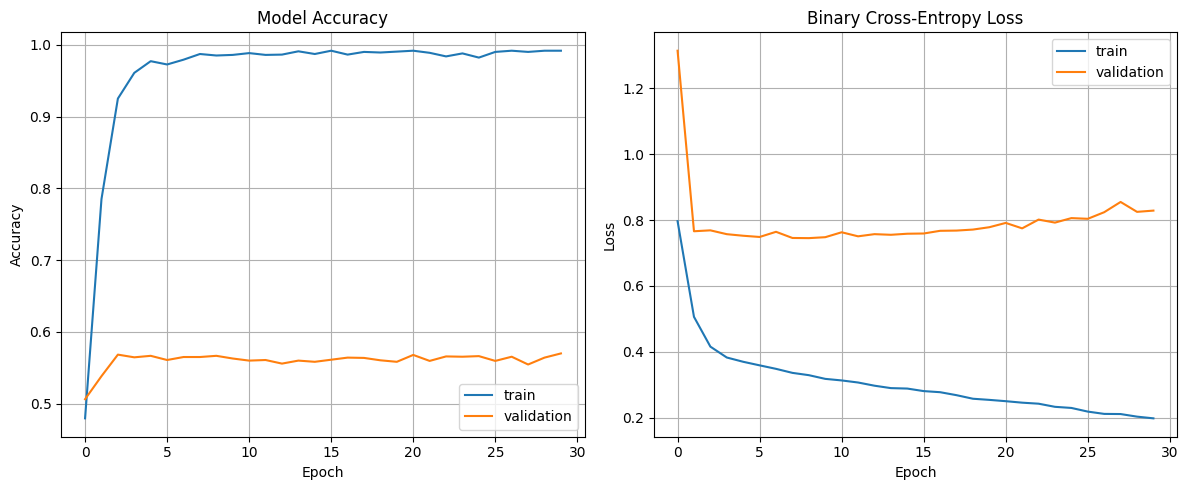

In [8]:
def plt_combined_metrics(history, has_valid=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Plot Accuracy ---
    axes[0].plot(history.history["accuracy"], label="train")
    if has_valid and "val_accuracy" in history.history:
        axes[0].plot(history.history["val_accuracy"], label="validation")
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # --- Plot Loss ---
    axes[1].plot(history.history["loss"], label="train")
    if has_valid and "val_loss" in history.history:
        axes[1].plot(history.history["val_loss"], label="validation")
    axes[1].set_title("Binary Cross-Entropy Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# execute the plotting function
plt_combined_metrics(history)

In [9]:
results = siamese_model.evaluate([x_test_1, x_test_2], labels_test, batch_size=16)
print("\nTest Loss, Test Acc:", results)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5617 - loss: 0.8262

Test Loss, Test Acc: [0.8456056714057922, 0.5733333230018616]


38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step


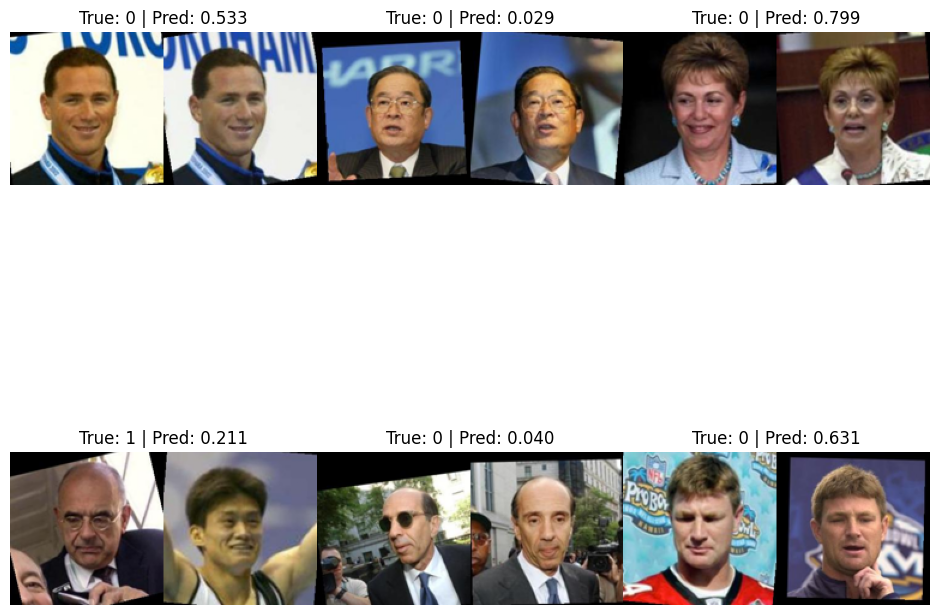

In [10]:
def visualize(pairs, labels, to_show=6, num_col=3, predictions=None, test=False):
    num_row = to_show // num_col if to_show // num_col != 0 else 1
    to_show = num_row * num_col

    fig, axes = plt.subplots(num_row, num_col, figsize=(5, 5))
    if to_show == 1:
        axes = [axes]
    if num_row > 1 and num_col > 1:
        axes = axes.flatten()

    for i in range(to_show):
        ax = axes[i]
        # We need to de-normalize the images from ResNet's [-1, 1] to [0, 1] for correct plotting
        img_pair_to_show = (pairs[i] / 2.0) + 0.5
        ax.imshow(ops.concatenate([img_pair_to_show[0], img_pair_to_show[1]], axis=1))
        ax.set_axis_off()
        if test:
            ax.set_title("True: {} | Pred: {:.3f}".format(int(labels[i]), predictions[i][0]))
        else:
            ax.set_title("Label: {}".format(int(labels[i])))
    if test:
        plt.tight_layout(rect=(0, 0, 1.9, 1.9), w_pad=0.0)
    else:
        plt.tight_layout(rect=(0, 0, 1.5, 1.5))
    # plt.tight_layout()
    plt.show()

predictions = siamese_model.predict([x_test_1, x_test_2])
visualize(data_test, labels_test, to_show=6, predictions=predictions, test=True)